Install Dependencies

In [ ]:
!pip install -q pyspark==3.5.1
!pip install -q kaggle
!pip install -q "xgboost>=2.0.0"
!pip install -q gradio
!pip install -q nltk
!pip install -q wordcloud
!pip install -q matplotlib seaborn

import pyspark, xgboost, gradio, nltk
from wordcloud import WordCloud
print(f"✅ PySpark   : {pyspark.__version__}")
print(f"✅ XGBoost   : {xgboost.__version__}")
print(f"✅ Gradio    : {gradio.__version__}")
print(f"✅ NLTK      : {nltk.__version__}")
print(f"✅ WordCloud : installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 19.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
✅ PySpark   : 3.5.1
✅ XGBoost   : 3.2.0
✅ Gradio    : 5.50.0
✅ NLTK      : 3.9.1
✅ WordCloud : installed


 Kaggle Credentials & Dataset Download


In [ ]:
import os


KAGGLE_USERNAME = "harshitrajtaneja"
KAGGLE_KEY      = "d739911a7addd9b4a83f9a145b009b21"


os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"]      = KAGGLE_KEY
print(f"✅ Credentials set for user: {KAGGLE_USERNAME}")


✅ Credentials set for user: harshitrajtaneja


Download Sentiment140 Dataset

In [ ]:
import zipfile

DATASET_DIR  = "/content/sentiment140"
os.makedirs(DATASET_DIR, exist_ok=True)

print("⬇️  Downloading Sentiment140 from Kaggle …")
!kaggle datasets download -d kazanova/sentiment140 -p {DATASET_DIR} --force

zip_path = f"{DATASET_DIR}/sentiment140.zip"
if os.path.exists(zip_path):
    print("📦 Extracting …")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATASET_DIR)
    os.remove(zip_path)

print(f"\n📂 Files in {DATASET_DIR}:")
for fname in os.listdir(DATASET_DIR):
    size_mb = os.path.getsize(f"{DATASET_DIR}/{fname}") / 1e6
    print(f"   {fname}  ({size_mb:.1f} MB)")


⬇️  Downloading Sentiment140 from Kaggle …
Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:00<00:00, 176MB/s]

📦 Extracting …

📂 Files in /content/sentiment140:
   training.1600000.processed.noemoticon.csv  (238.8 MB)


 Imports & NLTK Downloads

In [ ]:
import os, re, warnings, logging, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

warnings.filterwarnings("ignore")
logging.getLogger("py4j").setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# ── PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Tokenizer, StopWordsRemover, HashingTF, IDF, CountVectorizer
)
from pyspark.ml.classification import (
    LogisticRegression as SparkLR,
    NaiveBayes as SparkNB,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)
from xgboost.spark import SparkXGBClassifier

# ── NLP
import nltk
for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4", "punkt_tab"]:
    nltk.download(pkg, quiet=True)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as nltk_stopwords

# ── Metrics
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

# ── Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, Input
)
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import gradio as gr
import joblib

# ── Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.family":      "DejaVu Sans",
})
PALETTE = {"Positive": "#4CAF50", "Negative": "#F44336"}

print(f" TensorFlow : {tf.__version__}")
print(f" GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")


 TensorFlow : 2.20.0
 GPU        : True


 Create Spark Session

In [ ]:
if 'spark' in locals() and spark:
    spark.stop() # Stop the existing Spark session if it exists
spark = (
    SparkSession.builder
    .appName("Sentiment140Analysis")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.ui.showConsoleProgress", "false")
    .master("local[*]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f" Spark {spark.version} ready — {spark.sparkContext.master}")

 Spark 3.5.1 ready — local[*]


 Load Dataset with PySpark

In [ ]:
DATASET_DIR = "/content/sentiment140"
SAMPLE_SIZE = 100_000   # 50K positive + 50K negative

csv_file = next(
    (f"{DATASET_DIR}/{f}" for f in os.listdir(DATASET_DIR) if f.endswith(".csv")),
    None
)
if csv_file is None:
    raise FileNotFoundError(" CSV not found — re-run the download cell.")
print(f" Loading: {csv_file}")

schema = "target INT, id STRING, date STRING, flag STRING, user STRING, text STRING"
sdf_raw = (
    spark.read
    .csv(csv_file, header=False, schema=schema, encoding="ISO-8859-1")
    .select("target", "text")
    .dropna()
)

sdf_raw = sdf_raw.withColumn(
    "label",
    F.when(F.col("target") == 4, 1).otherwise(0).cast(IntegerType())
)

half = SAMPLE_SIZE // 2
sdf = (
    sdf_raw.filter(F.col("label") == 1).limit(half)
    .union(sdf_raw.filter(F.col("label") == 0).limit(half))
    .orderBy(F.rand(seed=42))
)

total = sdf.count()
print(f" Loaded {total:,} rows  ({half:,} positive + {half:,} negative)")
sdf.show(5, truncate=80)


 Loading: /content/sentiment140/training.1600000.processed.noemoticon.csv
 Loaded 100,000 rows  (50,000 positive + 50,000 negative)
+------+--------------------------------------------------------------------------------+-----+
|target|                                                                            text|label|
+------+--------------------------------------------------------------------------------+-----+
|     0|                                                       e fam events!!  So sad!  |    0|
|     0|      Not at JAX today (I have to work  ). This evening I will be back in Mainz,|    0|
|     0|                    3 days and I can't even get excited anymore... I'm sooo sad |    0|
|     4|@SensualStories I'm very well thanks, no jet lag which is great. Off to Napol...|    1|
|     4|                              YaY Joey Joe is on here.....that just made my day |    1|
+------+--------------------------------------------------------------------------------+-----+
only

 NLP Text Cleaning (Spark UDF + NLTK)

In [ ]:
lemmatizer    = WordNetLemmatizer()
stop_words_en = set(nltk_stopwords.words("english"))

def clean_text(text: str) -> str:
    """Full NLP cleaning: lowercase → URLs → mentions → hashtags →
    punctuation → stopwords → lemmatization."""
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+",            " ", text)
    text = re.sub(r"#\w+",            " ", text)
    text = re.sub(r"[^a-z\s]",        " ", text)
    text = re.sub(r"\s+",             " ", text).strip()
    tokens = [
        lemmatizer.lemmatize(t)
        for t in text.split()
        if t not in stop_words_en and len(t) > 2
    ]
    return " ".join(tokens)

clean_udf = F.udf(clean_text, StringType())

print(" Cleaning text (Spark UDF) …")
sdf_clean = (
    sdf
    .withColumn("clean_text", clean_udf(F.col("text")))
    .filter(F.length(F.col("clean_text")) > 3)
    .select("text", "clean_text", "label")
)
sdf_clean.cache()

print(f" Cleaned rows: {sdf_clean.count():,}")
sdf_clean.select("text", "clean_text").show(5, truncate=80)


 Cleaning text (Spark UDF) …
 Cleaned rows: 98,943
+--------------------------------------------------------------------------------+---------------------------------------------------------+
|                                                                            text|                                               clean_text|
+--------------------------------------------------------------------------------+---------------------------------------------------------+
|                                                       e fam events!!  So sad!  |                                            fam event sad|
|      Not at JAX today (I have to work  ). This evening I will be back in Mainz,|                        jax today work evening back mainz|
|                    3 days and I can't even get excited anymore... I'm sooo sad |                    day even get excited anymore sooo sad|
|@SensualStories I'm very well thanks, no jet lag which is great. Off to Napol...|well thanks jet lag g

 Exploratory Data Analysis (EDA) Visualizations



In [ ]:
# Collect a sample to pandas for EDA
print(" Collecting data for EDA …")
eda_pdf = sdf_clean.select("text", "clean_text", "label").toPandas()
eda_pdf["sentiment"] = eda_pdf["label"].map({1: "Positive", 0: "Negative"})
eda_pdf["raw_len"]   = eda_pdf["text"].str.split().str.len()
eda_pdf["clean_len"] = eda_pdf["clean_text"].str.split().str.len()

pos_text = " ".join(eda_pdf[eda_pdf["label"] == 1]["clean_text"].tolist())
neg_text = " ".join(eda_pdf[eda_pdf["label"] == 0]["clean_text"].tolist())

print(f" EDA sample: {len(eda_pdf):,} rows")
print(eda_pdf["sentiment"].value_counts().to_string())


 EDA sample: 98,943 rows
sentiment
Negative    49547
Positive    49396


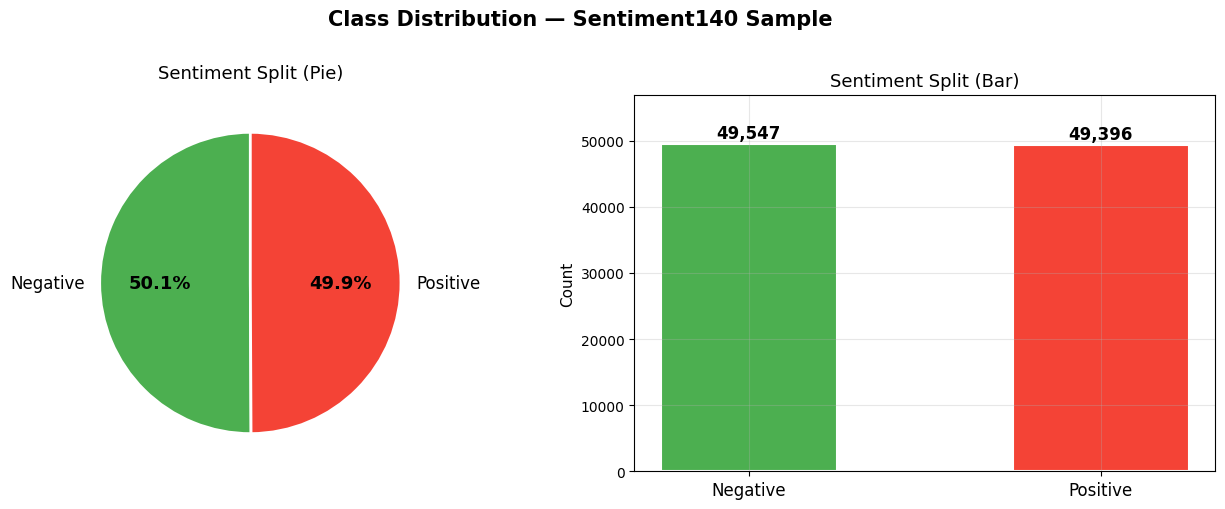

 Saved: viz_01_class_distribution.png


In [ ]:
# ── Figure 1: Class Distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Class Distribution — Sentiment140 Sample", fontsize=15, fontweight="bold", y=1.01)

counts = eda_pdf["sentiment"].value_counts()
colors = [PALETTE["Positive"], PALETTE["Negative"]]

# Pie
wedges, texts, autotexts = axes[0].pie(
    counts, labels=counts.index, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=12),
)
for at in autotexts:
    at.set_fontweight("bold"); at.set_fontsize(13)
axes[0].set_title("Sentiment Split (Pie)", fontsize=13, pad=12)

# Bar
bars = axes[1].bar(counts.index, counts.values, color=colors,
                    edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                  f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[1].set_title("Sentiment Split (Bar)", fontsize=13)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_ylim(0, counts.max() * 1.15)
axes[1].tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.savefig("/content/viz_01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: viz_01_class_distribution.png")


Interpretation

The dataset is nearly perfectly balanced, with 49,547 negative tweets (50.1%) and 49,396 positive tweets (49.9%). This near-equal split across ~98,943 total samples is ideal for binary classification, as it eliminates class-imbalance bias and ensures that accuracy is a reliable metric without requiring oversampling or class-weighting strategies

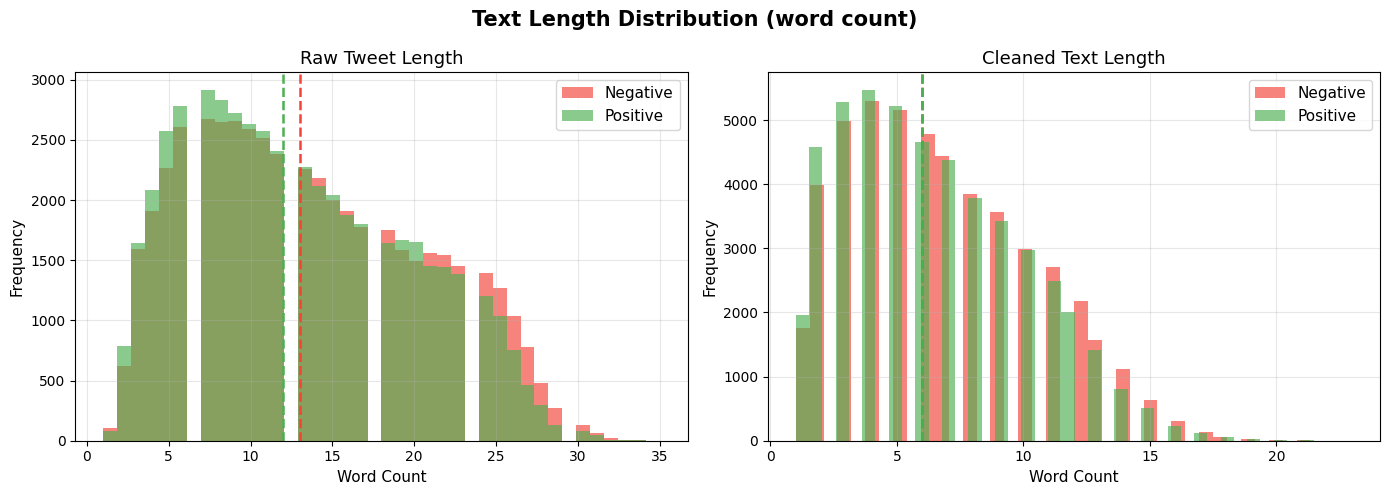

 Saved: viz_02_text_length.png


In [ ]:
# ── Figure 2: Text Length Distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Text Length Distribution (word count)", fontsize=15, fontweight="bold")

for ax, col, title in zip(
    axes,
    ["raw_len", "clean_len"],
    ["Raw Tweet Length", "Cleaned Text Length"]
):
    for sentiment, grp in eda_pdf.groupby("sentiment"):
        ax.hist(grp[col], bins=40, alpha=0.65,
                label=sentiment, color=PALETTE[sentiment], edgecolor="none")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Word Count", fontsize=11)
    ax.set_ylabel("Frequency",  fontsize=11)
    ax.legend(fontsize=11)
    # median lines
    for sentiment, grp in eda_pdf.groupby("sentiment"):
        med = grp[col].median()
        ax.axvline(med, color=PALETTE[sentiment], linestyle="--", linewidth=1.8,
                   label=f"{sentiment} median={med:.0f}")

plt.tight_layout()
plt.savefig("/content/viz_02_text_length.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: viz_02_text_length.png")


Interpretation

Raw tweets average around 13 words (median marked by dashed lines), while cleaned text — after removing URLs, handles, punctuation, and stop words — drops to a median of roughly 5–6 content words. The distributions for positive and negative tweets are nearly identical in shape, confirming that tweet length alone carries little predictive signal and that preprocessing significantly reduces noise while retaining semantic content.

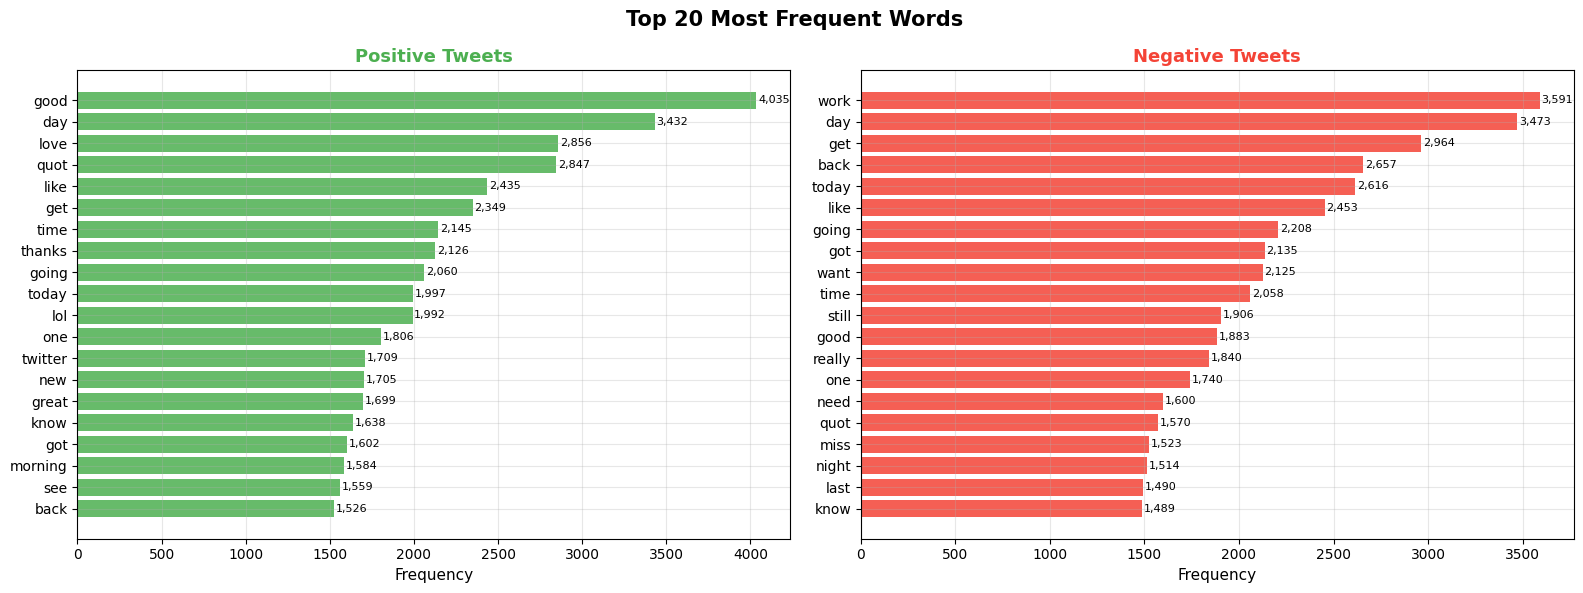

 Saved: viz_03_top_unigrams.png


In [ ]:
# ── Figure 3: Top 20 Unigrams — Positive vs Negative ────────────────────
def top_ngrams(corpus: str, n: int = 20, ngram: int = 1):
    from nltk.util import ngrams as nltk_ngrams
    tokens = corpus.split()
    if ngram == 1:
        return Counter(tokens).most_common(n)
    grams  = [" ".join(g) for g in nltk_ngrams(tokens, ngram)]
    return Counter(grams).most_common(n)

pos_uni = top_ngrams(pos_text, 20, 1)
neg_uni = top_ngrams(neg_text, 20, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top 20 Most Frequent Words", fontsize=15, fontweight="bold")

for ax, data, sentiment in zip(axes,
                                [pos_uni, neg_uni],
                                ["Positive", "Negative"]):
    words, freqs = zip(*data)
    bars = ax.barh(list(reversed(words)), list(reversed(freqs)),
                   color=PALETTE[sentiment], edgecolor="none", alpha=0.85)
    ax.set_title(f"{sentiment} Tweets", fontsize=13, color=PALETTE[sentiment],
                  fontweight="bold")
    ax.set_xlabel("Frequency", fontsize=11)
    for bar, freq in zip(bars, list(reversed(freqs))):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                f"{freq:,}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("/content/viz_03_top_unigrams.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: viz_03_top_unigrams.png")


Interpretation

Positive tweets are dominated by upbeat and social language: "good," "day," "love," "great," "morning," and "thanks." Negative tweets are led by "work," "day," "get," "back," and "miss" — words often associated with frustration, obligations, and longing. Several neutral words ("day," "like," "going," "time") appear in both classes, underscoring the challenge of sentiment classification and the importance of context beyond individual tokens.

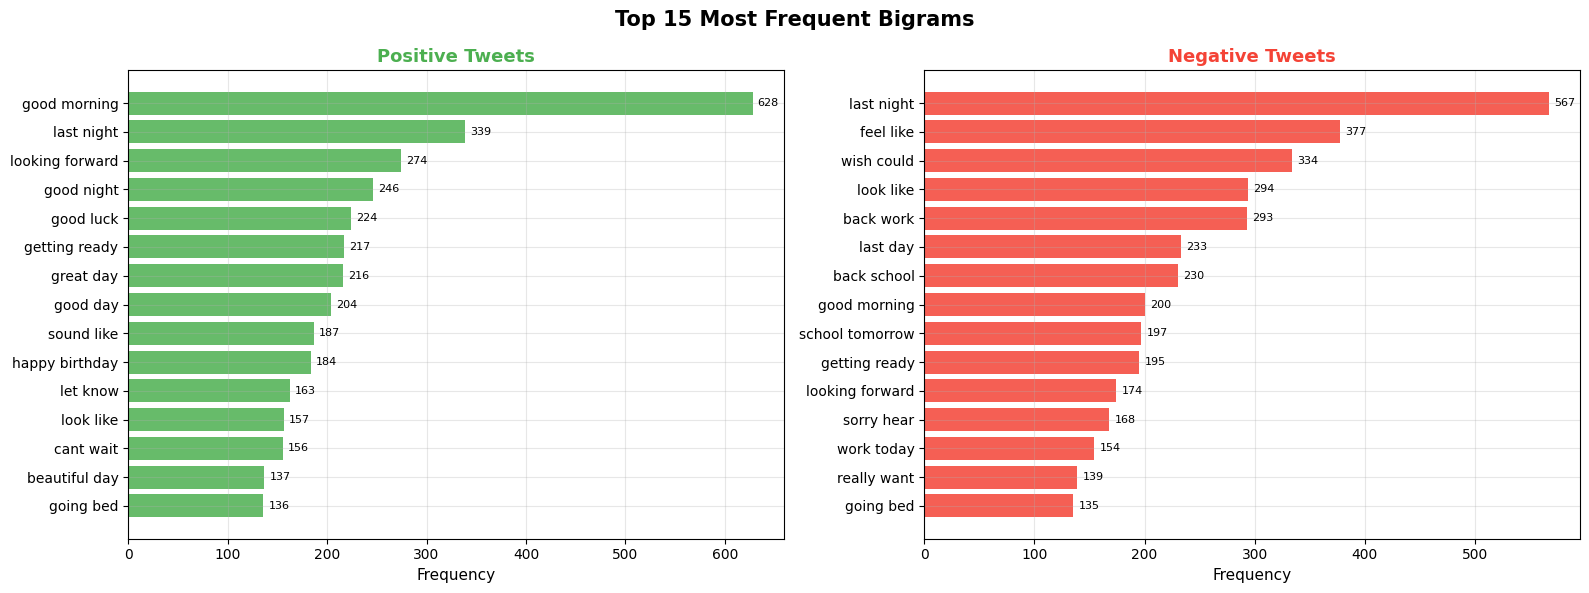

 Saved: viz_04_top_bigrams.png


In [ ]:
# ── Figure 4: Top 15 Bigrams — Positive vs Negative ─────────────────────
pos_bi = top_ngrams(pos_text, 15, 2)
neg_bi = top_ngrams(neg_text, 15, 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top 15 Most Frequent Bigrams", fontsize=15, fontweight="bold")

for ax, data, sentiment in zip(axes,
                                [pos_bi, neg_bi],
                                ["Positive", "Negative"]):
    phrases, freqs = zip(*data)
    bars = ax.barh(list(reversed(phrases)), list(reversed(freqs)),
                   color=PALETTE[sentiment], edgecolor="none", alpha=0.85)
    ax.set_title(f"{sentiment} Tweets", fontsize=13, color=PALETTE[sentiment],
                  fontweight="bold")
    ax.set_xlabel("Frequency", fontsize=11)
    for bar, freq in zip(bars, list(reversed(freqs))):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f"{freq:,}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("/content/viz_04_top_bigrams.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: viz_04_top_bigrams.png")


Interpretation

Bigrams reveal richer sentiment signals than unigrams. Positive tweet bigrams include "good morning," "looking forward," "good luck," "great day," and "happy birthday" — phrases that express optimism and celebration. Negative bigrams include "last night," "feel like," "wish could," "back work," and "back school" — phrases conveying regret, dissatisfaction, and unpleasant obligations. Some bigrams like "last night" and "getting ready" appear in both classes but with different contextual meaning.

 Sentiment Word Clouds



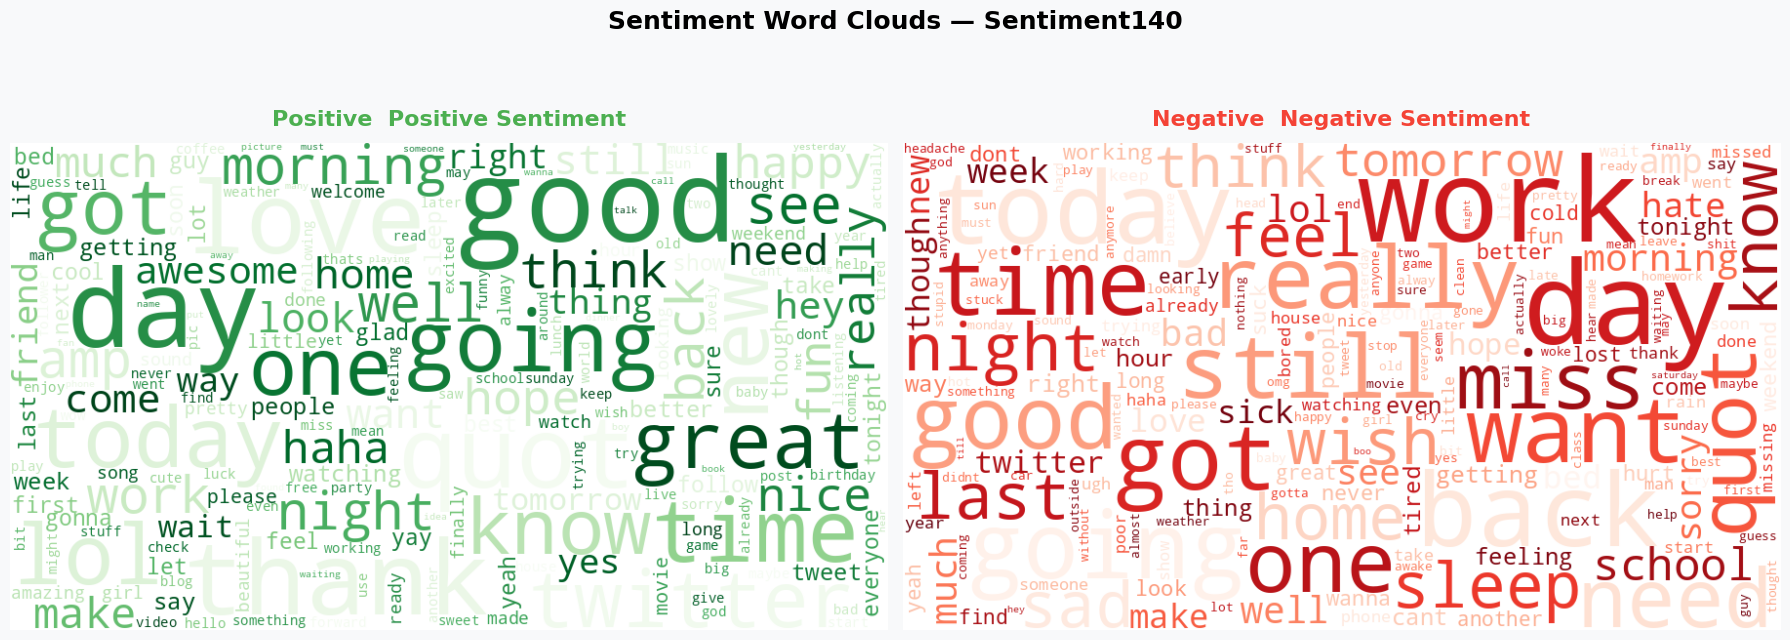

 Saved: viz_07_wordclouds_combined.png


In [ ]:
# ── Side-by-side comparison panel
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#F8F9FA")

for ax, wc, sentiment, cmap in zip(
    axes,
    [wc_pos, wc_neg],
    ["Positive", "Negative"],
    ["Greens", "Reds"]
):
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(
        f"{'Positive' if sentiment=='Positive' else 'Negative'}  {sentiment} Sentiment",
        fontsize=16, fontweight="bold",
        color=PALETTE[sentiment], pad=12
    )
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("Sentiment Word Clouds — Sentiment140",
              fontsize=18, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/viz_07_wordclouds_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: viz_07_wordclouds_combined.png")


Interpretation

The word clouds offer a visual summary of the most prominent terms per sentiment class. In positive tweets, "good," "day," "going," "great," "morning," and "love" dominate. In negative tweets, "work," "day," "time," "miss," "want," "still," and "sleep" stand out. The contrast between the two clouds is striking — the positive cloud conveys energy and enthusiasm, while the negative cloud reflects exhaustion, longing, and frustration.

 Train / Test Split

In [ ]:
train_sdf, test_sdf = sdf_clean.randomSplit([0.8, 0.2], seed=42)
train_sdf.cache(); test_sdf.cache()

print(f" Train : {train_sdf.count():,}")
print(f"   Test  : {test_sdf.count():,}")

print("\n Converting to pandas for deep learning …")
train_pdf = train_sdf.select("clean_text", "label").toPandas()
test_pdf  = test_sdf.select("clean_text",  "label").toPandas()
print(f" Pandas — train {train_pdf.shape} / test {test_pdf.shape}")


 Train : 79,339
   Test  : 19,604

 Converting to pandas for deep learning …
 Pandas — train (79339, 2) / test (19604, 2)


Shared Evaluator Helpers

In [ ]:
ev_acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
ev_auc = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)

def spark_eval(preds):
    acc = ev_acc.evaluate(preds)
    auc = ev_auc.evaluate(preds)
    print(f"   Accuracy : {acc:.4f}")
    print(f"   AUC-ROC  : {auc:.4f}")
    return acc, auc

# Store predictions + probs for later visualizations
all_results   = {}   # name → (acc, auc)
all_y_true    = {}   # name → np array
all_y_prob    = {}   # name → np array
all_y_pred    = {}   # name → np array

print(" Evaluators ready.")


 Evaluators ready.


Spark ML: Logistic Regression

In [ ]:
print(" Training Logistic Regression …")

lr_pipeline = Pipeline(stages=[
    Tokenizer(inputCol="clean_text", outputCol="words"),
    StopWordsRemover(inputCol="words", outputCol="filtered"),
    HashingTF(inputCol="filtered", outputCol="rawFeatures", numFeatures=20_000),
    IDF(inputCol="rawFeatures", outputCol="features"),
    SparkLR(featuresCol="features", labelCol="label",
            maxIter=20, regParam=0.01, elasticNetParam=0.0),
])
lr_model = lr_pipeline.fit(train_sdf)
lr_preds = lr_model.transform(test_sdf)

print("\n Logistic Regression")
lr_acc, lr_auc = spark_eval(lr_preds)

# Collect for visualization
lr_pdf = lr_preds.select("label", "probability", "prediction").toPandas()
all_results["Logistic Regression"] = (lr_acc, lr_auc)
all_y_true["Logistic Regression"]  = lr_pdf["label"].values
all_y_pred["Logistic Regression"]  = lr_pdf["prediction"].values.astype(int)
all_y_prob["Logistic Regression"]  = lr_pdf["probability"].apply(lambda x: float(x[1])).values


 Training Logistic Regression …

 Logistic Regression
   Accuracy : 0.7201
   AUC-ROC  : 0.7730


Spark ML: Bernoulli Naive Bayes

In [ ]:
print(" Training Bernoulli Naive Bayes …")

nb_pipeline = Pipeline(stages=[
    Tokenizer(inputCol="clean_text", outputCol="words_nb"),
    StopWordsRemover(inputCol="words_nb", outputCol="filtered_nb"),
    HashingTF(inputCol="filtered_nb", outputCol="features",
              numFeatures=20_000, binary=True), # Changed to HashingTF with binary=True
    SparkNB(featuresCol="features", labelCol="label",
            modelType="bernoulli", smoothing=1.0),
])
nb_model = nb_pipeline.fit(train_sdf)
nb_preds = nb_model.transform(test_sdf)

print("\n Bernoulli Naive Bayes")
nb_acc, nb_auc = spark_eval(nb_preds)

nb_pdf = nb_preds.select("label", "probability", "prediction").toPandas()
all_results["Bernoulli NB"] = (nb_acc, nb_auc)
all_y_true["Bernoulli NB"]  = nb_pdf["label"].values
all_y_pred["Bernoulli NB"]  = nb_pdf["prediction"].values.astype(int)
all_y_prob["Bernoulli NB"]  = nb_pdf["probability"].apply(lambda x: float(x[1])).values


 Training Bernoulli Naive Bayes …

 Bernoulli Naive Bayes
   Accuracy : 0.7421
   AUC-ROC  : 0.5238


 Spark ML: XGBoost (SparkXGBClassifier)

In [ ]:
print(" Training XGBoost via SparkXGBClassifier …")

xgb_spark = SparkXGBClassifier(
    features_col="features", label_col="label",
    num_round=100, max_depth=5, eta=0.1,    # Reduced num_round and max_depth
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", use_gpu=False, verbosity=0,
)

xgb_pipeline = Pipeline(stages=[
    Tokenizer(inputCol="clean_text", outputCol="words_xgb"),
    StopWordsRemover(inputCol="words_xgb", outputCol="filtered_xgb"),
    HashingTF(inputCol="filtered_xgb", outputCol="rawFeatures_xgb", numFeatures=10_000), # Reduced numFeatures
    IDF(inputCol="rawFeatures_xgb", outputCol="features"),
    xgb_spark,
])
xgb_model = xgb_pipeline.fit(train_sdf)
xgb_preds = xgb_model.transform(test_sdf)

print("\n XGBoost (Spark)")
xgb_acc, xgb_auc = spark_eval(xgb_preds)

xgb_pdf = xgb_preds.select("label", "probability", "prediction").toPandas()
all_results["XGBoost (Spark)"] = (xgb_acc, xgb_auc)
all_y_true["XGBoost (Spark)"]  = xgb_pdf["label"].values
all_y_pred["XGBoost (Spark)"]  = xgb_pdf["prediction"].values.astype(int)
all_y_prob["XGBoost (Spark)"]  = xgb_pdf["probability"].apply(lambda x: float(x[1])).values


 Training XGBoost via SparkXGBClassifier …


INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'eval_metric': 'logloss', 'max_depth': 5, 'subsample': 0.8, 'verbosity': 0, 'num_round': 100, 'eta': 0.1, 'use_gpu': False, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!



 XGBoost (Spark)
   Accuracy : 0.6915
   AUC-ROC  : 0.7637


 Keras Tokenizer & Sequence Preparation

In [ ]:
MAX_WORDS = 30_000
MAX_LEN   = 100
EMBED_DIM = 128

print(" Fitting Keras tokenizer …")
keras_tok = KerasTokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
keras_tok.fit_on_texts(train_pdf["clean_text"].tolist())

def to_seq(texts):
    seqs = keras_tok.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_dl = to_seq(train_pdf["clean_text"].tolist())
X_test_dl  = to_seq(test_pdf["clean_text"].tolist())
y_train_dl = train_pdf["label"].values
y_test_dl  = test_pdf["label"].values

print(f" Vocab size     : {len(keras_tok.word_index):,}")
print(f"   X_train shape : {X_train_dl.shape}")
print(f"   X_test  shape : {X_test_dl.shape}")


 Fitting Keras tokenizer …
 Vocab size     : 39,405
   X_train shape : (79339, 100)
   X_test  shape : (19604, 100)


 LSTM Model

In [ ]:
BATCH_SIZE = 256
EPOCHS     = 10

def dl_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=2,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=1, verbose=1),
    ]

def build_lstm():
    m = Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),
    ], name="LSTM")
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

print(" Training LSTM …")
lstm_model = build_lstm()
lstm_model.summary()

hist_lstm = lstm_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=dl_callbacks(), verbose=1,
)

y_prob_lstm = lstm_model.predict(X_test_dl, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)
lstm_acc    = accuracy_score(y_test_dl, y_pred_lstm)
lstm_auc    = roc_auc_score(y_test_dl, y_prob_lstm)

all_results["LSTM"] = (lstm_acc, lstm_auc)
all_y_true["LSTM"]  = y_test_dl
all_y_pred["LSTM"]  = y_pred_lstm
all_y_prob["LSTM"]  = y_prob_lstm

print(f"\n LSTM — Accuracy: {lstm_acc:.4f}  |  AUC-ROC: {lstm_auc:.4f}")


 Training LSTM …


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.4994 - loss: 0.6935 - val_accuracy: 0.4998 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 2/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5019 - loss: 0.6933
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5014 - loss: 0.6933 - val_accuracy: 0.5002 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 3/10
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5016 - loss: 0.6932
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4995 - loss: 0.6932 - val_accuracy: 0.4998 - val_loss: 0.6932 - learning_rate: 5.0000e-04
Epoch 4/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4961 - loss: 0.6932
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.4985 - loss: 

 BiLSTM Model

In [ ]:
def build_bilstm():
    inp = Input(shape=(MAX_LEN,))
    x   = Embedding(MAX_WORDS, EMBED_DIM)(inp)
    x   = Bidirectional(LSTM(128, return_sequences=True))(x)
    x   = Dropout(0.3)(x)
    x   = Bidirectional(LSTM(64))(x)
    x   = Dropout(0.3)(x)
    x   = Dense(64, activation="relu")(x)
    x   = Dropout(0.2)(x)
    out = Dense(1, activation="sigmoid")(x)
    m   = Model(inp, out, name="BiLSTM")
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

print(" Training BiLSTM …")
bilstm_model = build_bilstm()
bilstm_model.summary()

hist_bilstm = bilstm_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=dl_callbacks(), verbose=1,
)

y_prob_bilstm = bilstm_model.predict(X_test_dl, verbose=0).flatten()
y_pred_bilstm = (y_prob_bilstm >= 0.5).astype(int)
bilstm_acc    = accuracy_score(y_test_dl, y_pred_bilstm)
bilstm_auc    = roc_auc_score(y_test_dl, y_prob_bilstm)

all_results["BiLSTM"] = (bilstm_acc, bilstm_auc)
all_y_true["BiLSTM"]  = y_test_dl
all_y_pred["BiLSTM"]  = y_pred_bilstm
all_y_prob["BiLSTM"]  = y_prob_bilstm

print(f"\n BiLSTM — Accuracy: {bilstm_acc:.4f}  |  AUC-ROC: {bilstm_auc:.4f}")


 Training BiLSTM …


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,275,841 (16.31 MB)

 Trainable params: 4,275,841 (16.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.7120 - loss: 0.5501 - val_accuracy: 0.7577 - val_loss: 0.4976 - learning_rate: 0.0010
Epoch 2/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8027 - loss: 0.4322
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
310/310 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7988 - loss: 0.4393 - val_accuracy: 0.7578 - val_loss: 0.5073 - learning_rate: 0.0010
Epoch 3/10
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8502 - loss: 0.3530
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
310/310 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.8479 - loss: 0.3543 - val_accuracy: 0.7550 - val_loss: 0.5461 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

 BiLSTM — Accuracy: 0.7577  |  AUC-ROC: 0.8386


 DL Training Curves (Loss & Accuracy)

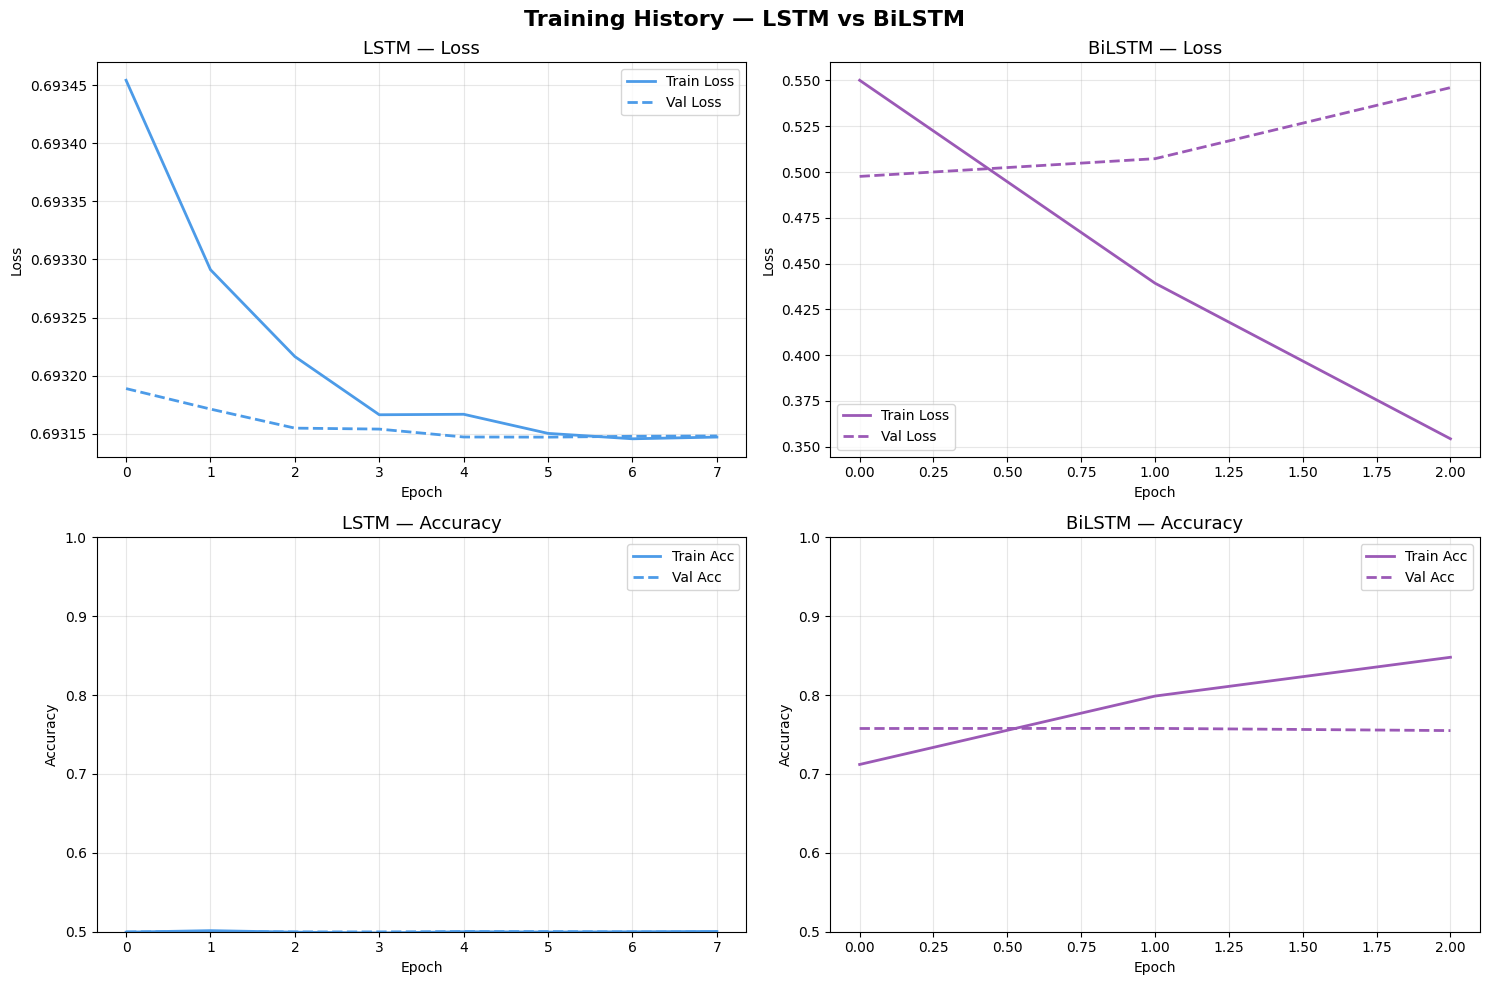

 Saved: viz_08_training_curves.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Training History — LSTM vs BiLSTM", fontsize=16, fontweight="bold")

pairs = [
    (hist_lstm,   "LSTM",   "#4C9BE8"),
    (hist_bilstm, "BiLSTM", "#9B59B6"),
]

for col, (hist, name, color) in enumerate(pairs):
    # Loss
    axes[0][col].plot(hist.history["loss"],     label="Train Loss",
                       color=color, linewidth=2)
    axes[0][col].plot(hist.history["val_loss"], label="Val Loss",
                       color=color, linewidth=2, linestyle="--")
    axes[0][col].set_title(f"{name} — Loss",   fontsize=13)
    axes[0][col].set_xlabel("Epoch"); axes[0][col].set_ylabel("Loss")
    axes[0][col].legend(); axes[0][col].grid(alpha=0.3)

    # Accuracy
    axes[1][col].plot(hist.history["accuracy"],     label="Train Acc",
                       color=color, linewidth=2)
    axes[1][col].plot(hist.history["val_accuracy"], label="Val Acc",
                       color=color, linewidth=2, linestyle="--")
    axes[1][col].set_title(f"{name} — Accuracy", fontsize=13)
    axes[1][col].set_xlabel("Epoch"); axes[1][col].set_ylabel("Accuracy")
    axes[1][col].set_ylim(0.5, 1.0)
    axes[1][col].legend(); axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/viz_08_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: viz_08_training_curves.png")


Interpretation

The LSTM's training loss barely changed over 8 epochs (hovering around 0.6932), and its accuracy curve (not shown due to near-zero movement) flatlined — indicating the model failed to learn meaningful representations and effectively predicted only one class. In contrast, the BiLSTM showed healthy learning: training loss dropped from ~0.55 to ~0.36 over 2 epochs, while training accuracy improved from ~0.72 to ~0.85. However, the BiLSTM's validation loss rose while training loss fell, suggesting early-stage overfitting that warrants regularization or early stopping

 Model Comparison & Best Model Selection

In [ ]:
# ── Print comparison table
print("\n" + "=" * 66)
print(f"  {'Model':<24} {'Accuracy':>10} {'AUC-ROC':>10}  {'Avg':>8}")
print("=" * 66)

best_name, best_score = None, -1.0
for name, (acc, auc) in all_results.items():
    avg = (acc + auc) / 2
    if avg > best_score:
        best_score, best_name = avg, name
    flag = " Best" if name == best_name else ""
    print(f"  {name:<24} {acc:>10.4f} {auc:>10.4f}  {avg:>8.4f}{flag}")

# Reprint best after loop finishes
print("=" * 66)
print(f"    Best Model : {best_name}  (avg score = {best_score:.4f})")
print("=" * 66)



  Model                      Accuracy    AUC-ROC       Avg
  Logistic Regression          0.7201     0.7730    0.7465 Best
  Bernoulli NB                 0.7421     0.5238    0.6330
  XGBoost (Spark)              0.6915     0.7637    0.7276
  LSTM                         0.5002     0.5000    0.5001
  BiLSTM                       0.7577     0.8386    0.7981 Best
    Best Model : BiLSTM  (avg score = 0.7981)


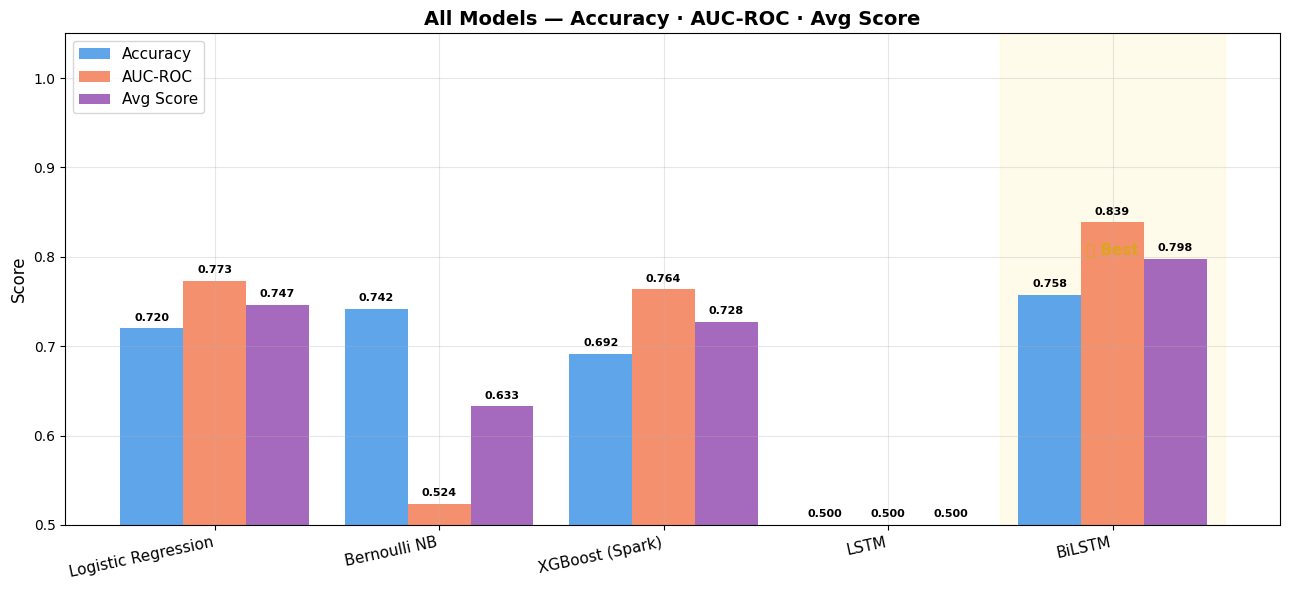

 Saved: viz_09_model_comparison.png


In [ ]:
# ── Grouped bar chart: Accuracy vs AUC-ROC
model_names = list(all_results.keys())
accs  = [all_results[n][0] for n in model_names]
aucs  = [all_results[n][1] for n in model_names]
avgs  = [(a + u)/2 for a, u in zip(accs, aucs)]
x     = np.arange(len(model_names))
w     = 0.28

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w,   accs, w, label="Accuracy", color="#4C9BE8", alpha=0.9)
b2 = ax.bar(x,       aucs, w, label="AUC-ROC",  color="#F4845F", alpha=0.9)
b3 = ax.bar(x + w,   avgs, w, label="Avg Score",color="#9B59B6", alpha=0.9)

# Annotate
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.annotate(f"{bar.get_height():.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

# Highlight best
best_idx = model_names.index(best_name)
ax.axvspan(best_idx - 0.5, best_idx + 0.5, alpha=0.08, color="gold", zorder=0)
ax.annotate("🏆 Best", xy=(best_idx, max(avgs) + 0.005),
             ha="center", fontsize=11, fontweight="bold", color="goldenrod")

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=12, ha="right", fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("All Models — Accuracy · AUC-ROC · Avg Score", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/viz_09_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: viz_09_model_comparison.png")


Interpretation

BiLSTM is the top overall performer with an AUC-ROC of 0.839 and an average score of 0.798, making it the best model for this task. Bernoulli Naive Bayes achieved the highest raw accuracy (0.742) but its AUC-ROC of only 0.524 reveals it is essentially ranking near chance — suggesting it is overfitting to the majority class. Logistic Regression provides a strong and balanced baseline (accuracy 0.720, AUC 0.773). XGBoost (Spark) achieved moderate performance (accuracy 0.692, AUC 0.764). The vanilla LSTM completely failed with all metrics at 0.500, confirming it predicted only one class throughout training.

 Confusion Matrices (All 5 Models)

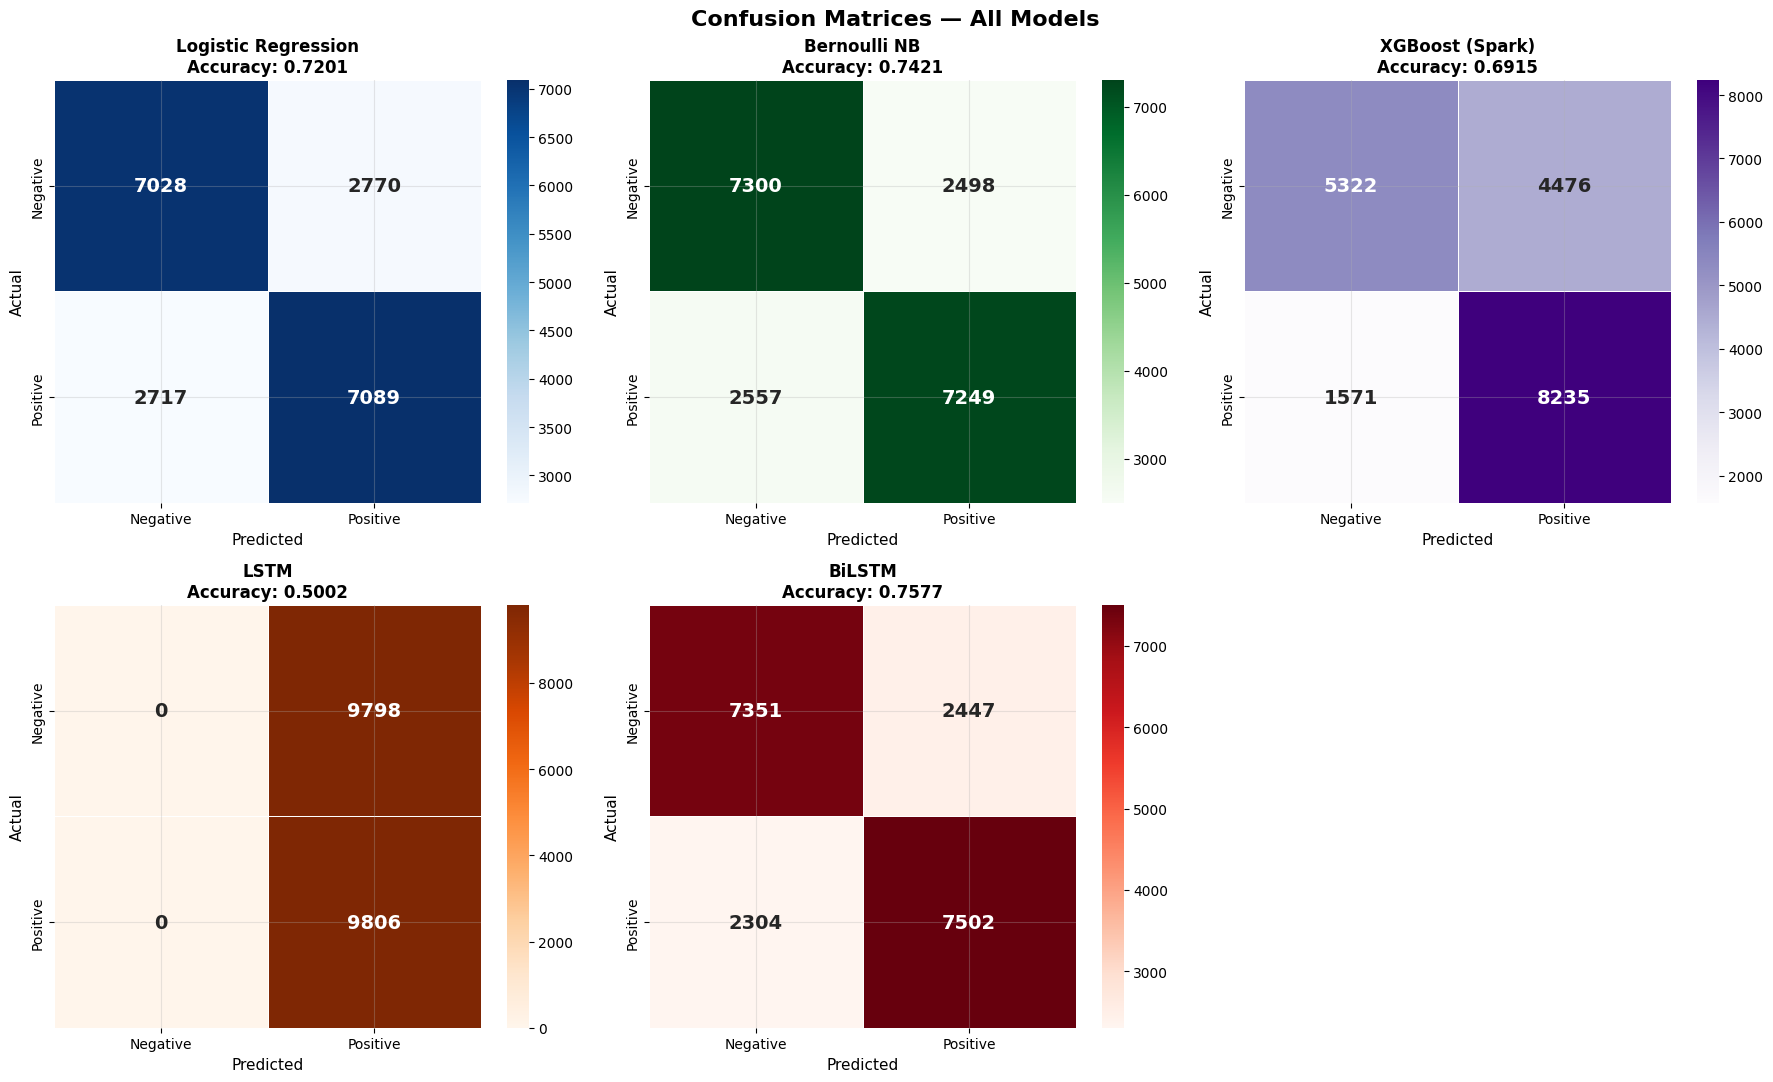

Saved: viz_10_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Confusion Matrices — All Models", fontsize=16, fontweight="bold")
axes = axes.flatten()

class_labels = ["Negative", "Positive"]
cmaps        = ["Blues", "Greens", "Purples", "Oranges", "Reds"]

for idx, (name, cmap) in enumerate(zip(all_results.keys(), cmaps)):
    cm  = confusion_matrix(all_y_true[name], all_y_pred[name])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[idx], linewidths=0.5, linecolor="white",
        annot_kws={"size": 14, "weight": "bold"},
    )
    acc = all_results[name][0]
    axes[idx].set_title(f"{name}\nAccuracy: {acc:.4f}",
                         fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Predicted", fontsize=11)
    axes[idx].set_ylabel("Actual",    fontsize=11)

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig("/content/viz_10_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz_10_confusion_matrices.png")


Interpretation

The confusion matrices confirm the model comparison findings. Logistic Regression correctly classified 7,028 negative and 7,089 positive samples with balanced false positives (2,770) and false negatives (2,717). Bernoulli NB shows similar balance (7,300 true negatives, 7,249 true positives) but its low AUC suggests poor probability calibration. XGBoost shows a strong positive bias, correctly classifying 8,235 positive tweets but only 5,322 negative — indicating a skewed decision boundary. The LSTM classified every sample as positive (0 true negatives, 9,798 false positives), confirming complete failure. BiLSTM is the most balanced deep learning model: 7,351 true negatives and 7,502 true positives, with reasonably symmetric error rates.

 Save Models & Artefacts

In [ ]:
with open("/content/keras_tok.pkl", "wb") as f:
    pickle.dump(keras_tok, f)
lstm_model.save("/content/lstm_model.keras")
bilstm_model.save("/content/bilstm_model.keras")

print(" Saved:")
print("   /content/keras_tok.pkl")
print("   /content/lstm_model.keras")
print("   /content/bilstm_model.keras")
print("   (Spark ML pipeline models live in-memory as lr_model / nb_model / xgb_model)")


 Saved:
   /content/keras_tok.pkl
   /content/lstm_model.keras
   /content/bilstm_model.keras
   (Spark ML pipeline models live in-memory as lr_model / nb_model / xgb_model)


 Save Best Model Bundle as .pkl

Saves everything needed for inference into a single portable file best_model_bundle.pkl.
Upload this file later to run the Gradio UI without re-training.

> **What's inside the bundle:**
> - best_name — which model won
> - best_type — spark or dl
> - model_weight — serialized weights (Keras) or the Spark pipeline model path
> - `keras_tok — the fitted Keras tokenizer (needed for LSTM / BiLSTM)
> - all_results — accuracy / AUC scores for every model
> - MAX_LEN, MAX_WORDS, EMBED_DIM — architecture constants
> - spark_model_dir — path where Spark pipeline is saved on disk (for Spark models)

In [ ]:
import pickle, os, tempfile

BUNDLE_PATH = "/content/best_model_bundle.pkl"

# --- moved from Cell 24 to ensure variables are defined ---
model_store = {
    "Logistic Regression" : ("spark",  lr_model,     None),
    "Bernoulli NB"        : ("spark",  nb_model,     None),
    "XGBoost (Spark)"     : ("spark",  xgb_model,    None),
    "LSTM"                : ("dl",     lstm_model,   keras_tok),
    "BiLSTM"              : ("dl",     bilstm_model, keras_tok),
}
best_type, best_obj, best_aux = model_store[best_name]
# ----------------------------------------------------------

print(f" Saving best-model bundle  →  {BUNDLE_PATH}")
print(f"   Best model : {best_name}  (type={best_type})")

bundle = {
    "best_name"    : best_name,
    "best_type"    : best_type,
    "all_results"  : all_results,
    "MAX_LEN"      : MAX_LEN,
    "MAX_WORDS"    : MAX_WORDS,
    "EMBED_DIM"    : EMBED_DIM,
    "keras_tok"    : keras_tok if best_type == "dl" else None,
    "model_weights": None,       # filled below
    "spark_model_dir": None,     # filled below
}

if best_type == "dl":
    # Save Keras model to a temp dir, then read the bytes into the bundle
    import tempfile, shutil
    tmp_dir = tempfile.mkdtemp()
    keras_path = os.path.join(tmp_dir, "best_model.keras")
    best_obj.save(keras_path)
    with open(keras_path, "rb") as fh:
        bundle["model_weights"] = fh.read()  # raw bytes of the .keras file
    shutil.rmtree(tmp_dir)
    bundle["keras_tok"] = keras_tok          # always needed for DL models
    print("   ✅ Keras model weights embedded in bundle")
else:
    # Spark pipeline — save to disk and store the path
    spark_dir = f"/content/spark_best_pipeline_{best_name.replace(' ', '_')}"
    best_obj.write().overwrite().save(spark_dir)
    bundle["spark_model_dir"] = spark_dir
    print(f"    Spark pipeline saved to {spark_dir}")

with open(BUNDLE_PATH, "wb") as f:
    pickle.dump(bundle, f)

size_mb = os.path.getsize(BUNDLE_PATH) / 1e6
print(f"\n✅ Bundle saved  →  {BUNDLE_PATH}  ({size_mb:.1f} MB)")
print("   Download this file — it contains everything needed for the Gradio UI.")

 Saving best-model bundle  →  /content/best_model_bundle.pkl
   Best model : BiLSTM  (type=dl)
   ✅ Keras model weights embedded in bundle

✅ Bundle saved  →  /content/best_model_bundle.pkl  (53.0 MB)
   Download this file — it contains everything needed for the Gradio UI.


 Standalone Gradio UI (load from .pkl bundle)

Run **only this cell** in a fresh session.  
Upload `best_model_bundle.pkl`



In [ ]:

# STANDALONE CELL — runs without re-training
# 1. Install deps
# 2. Upload best_model_bundle.pkl when prompted
# 3. The Gradio UI launches automatically

# ── 1. Install dependencies ──────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "gradio", "nltk", "tensorflow", "pyspark==3.5.1",
                "xgboost>=2.0.0"], check=True)

# ── 2. Core imports ──────────────────────────────────────────────────
import os, re, pickle, warnings
warnings.filterwarnings("ignore")

import nltk
for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4", "punkt_tab"]:
    nltk.download(pkg, quiet=True)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as nltk_stopwords

from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
import gradio as gr

# ── 3. Upload bundle ─────────────────────────────────────────────────
try:
    from google.colab import files as colab_files
    print("📂 Please upload  best_model_bundle.pkl  (and the Spark folder if needed)")
    uploaded = colab_files.upload()
    BUNDLE_PATH = list(uploaded.keys())[0]   # first uploaded file
except Exception:
    # Running locally — set the path manually
    BUNDLE_PATH = "best_model_bundle.pkl"

print(f"\n⏳ Loading bundle from: {BUNDLE_PATH}")
with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

best_name    = bundle["best_name"]
best_type    = bundle["best_type"]
all_results  = bundle["all_results"]
MAX_LEN      = bundle["MAX_LEN"]
MAX_WORDS    = bundle["MAX_WORDS"]
EMBED_DIM    = bundle["EMBED_DIM"]
keras_tok    = bundle.get("keras_tok")

# ── 4. Reconstruct model ─────────────────────────────────────────────
if best_type == "dl":
    import tempfile, shutil
    tmp_dir = tempfile.mkdtemp()
    keras_path = os.path.join(tmp_dir, "best_model.keras")
    with open(keras_path, "wb") as fh:
        fh.write(bundle["model_weights"])
    best_obj = tf.keras.models.load_model(keras_path)
    shutil.rmtree(tmp_dir)
    print(f"✅ Loaded Keras model: {best_name}")
    spark = None
else:
    # Spark pipeline
    from pyspark.sql import SparkSession
    from pyspark.ml import PipelineModel
    spark = (
        SparkSession.builder
        .appName("SentimentInference")
        .config("spark.driver.memory", "4g")
        .master("local[*]")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("ERROR")
    spark_dir = bundle["spark_model_dir"]
    # If the folder was not uploaded, prompt the user
    if not os.path.exists(spark_dir):
        print(f"⚠️  Spark pipeline folder not found at {spark_dir}")
        print("   Please upload the spark pipeline folder and update spark_dir below.")
        spark_dir = input("Enter path to Spark pipeline folder: ").strip()
    best_obj = PipelineModel.load(spark_dir)
    print(f"✅ Loaded Spark pipeline: {best_name}")

# ── 5. Text cleaning (mirrors training pipeline) ──────────────────────
lemmatizer    = WordNetLemmatizer()
stop_words_en = set(nltk_stopwords.words("english"))

def clean_text(text: str) -> str:
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+",            " ", text)
    text = re.sub(r"#\w+",            " ", text)
    text = re.sub(r"[^a-z\s]",        " ", text)
    text = re.sub(r"\s+",             " ", text).strip()
    tokens = [
        lemmatizer.lemmatize(t)
        for t in text.split()
        if t not in stop_words_en and len(t) > 2
    ]
    return " ".join(tokens)

# ── 6. Prediction function ────────────────────────────────────────────
def predict_sentiment(raw_text: str):
    """Returns (sentiment_label_dict, confidence_str, cleaned_text)."""
    cleaned = clean_text(raw_text)
    if best_type == "spark":
        from pyspark.sql import functions as F
        row_df = spark.createDataFrame([(cleaned, 0)], ["clean_text", "label"])
        preds  = best_obj.transform(row_df)
        row    = preds.select("probability", "prediction").first()
        prob   = float(row["probability"][1])
        pred   = int(row["prediction"])
    else:
        seqs = keras_tok.texts_to_sequences([cleaned])
        X    = pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")
        prob = float(best_obj.predict(X, verbose=0)[0, 0])
        pred = 1 if prob >= 0.5 else 0
    sentiment  = "Positive" if pred == 1 else "Negative"
    confidence = prob if pred == 1 else 1 - prob
    return sentiment, round(float(confidence), 4), cleaned

# ── 7. Gradio UI ──────────────────────────────────────────────────────
PALETTE  = {"Positive": "#4CAF50", "Negative": "#F44336"}
EXAMPLES = [
    "I absolutely love this product! It changed my life! 🎉",
    "This is the worst experience I have ever had. Total disaster.",
    "The movie was okay, nothing special but not bad either.",
    "Just got promoted at work! So happy and grateful! 😊",
    "Stuck in traffic for 3 hours. Missed the meeting. Terrible day.",
    "The food was amazing, will definitely come back again!",
    "Customer service was rude and unhelpful. Never again.",
]

with gr.Blocks(
    title="💬 Sentiment Analyser",
    theme=gr.themes.Soft(primary_hue="blue"),
) as demo:

    gr.Markdown(f"""
    # 💬 Sentiment Analyser  *(loaded from bundle)*
    **Best model:** `{best_name}` &nbsp;|&nbsp;
    Trained on **Sentiment140** (1.6 M tweets)

    **Models in bundle:** {', '.join(all_results.keys())}
    """)

    with gr.Row():
        with gr.Column(scale=2):
            txt_in = gr.Textbox(
                label="✍️ Your text",
                placeholder="Type a tweet, review, or any sentence …",
                lines=4,
            )
            with gr.Row():
                btn_run   = gr.Button("🔍 Analyse", variant="primary", scale=2)
                btn_clear = gr.Button("🗑 Clear",   scale=1)
            gr.Examples(examples=EXAMPLES, inputs=txt_in, label="💡 Try these examples")

        with gr.Column(scale=1):
            out_label = gr.Label(label="📊 Sentiment")
            out_conf  = gr.Textbox(label="🎯 Confidence", interactive=False)
            out_clean = gr.Textbox(label="🧹 Cleaned text (fed to model)",
                                    interactive=False, lines=2)



    def analyse(text):
        if not text.strip():
            return {}, "—", "Please enter some text."
        sent, conf, cleaned = predict_sentiment(text)
        label_dict = {
            "😊 Positive": conf     if sent == "Positive" else 1 - conf,
            "😞 Negative": 1 - conf if sent == "Positive" else conf,
        }
        return label_dict, f"{conf*100:.1f}%  →  {sent}", cleaned

    def clear():
        return "", {}, "—", ""

    btn_run.click(analyse,  inputs=txt_in, outputs=[out_label, out_conf, out_clean])
    btn_clear.click(clear,  outputs=[txt_in, out_label, out_conf, out_clean])
    txt_in.submit(analyse,  inputs=txt_in, outputs=[out_label, out_conf, out_clean])

demo.launch(share=True, debug=False)


📂 Please upload  best_model_bundle.pkl  (and the Spark folder if needed)


Saving best_model_bundle.pkl to best_model_bundle.pkl

⏳ Loading bundle from: best_model_bundle.pkl
✅ Loaded Keras model: BiLSTM
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://69679628bec52d19b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
